<a href="https://colab.research.google.com/github/ElenJ/QML-Course/blob/main/VAE_on_Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VAE on Iris

source: largely from https://pennylane.ai/qml/demos/tutorial_variational_classifier/

In [2]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 79.8 MB/s eta 0:00:00


Starting training...
Iter:     2 | Cost: 2.7553264 | Acc train: 0.0133333 | Acc validation: 0.0000000
Iter:     4 | Cost: 2.5355030 | Acc train: 0.0133333 | Acc validation: 0.0000000
Iter:     6 | Cost: 2.0158329 | Acc train: 0.0933333 | Acc validation: 0.0400000
Iter:     8 | Cost: 1.2349024 | Acc train: 0.2933333 | Acc validation: 0.2000000
Iter:    10 | Cost: 0.6635029 | Acc train: 0.8266667 | Acc validation: 0.8800000
Iter:    12 | Cost: 0.4734509 | Acc train: 0.8000000 | Acc validation: 0.8800000
Iter:    14 | Cost: 0.4373628 | Acc train: 0.8533333 | Acc validation: 0.8800000
Iter:    16 | Cost: 0.3809849 | Acc train: 0.9333333 | Acc validation: 0.8800000
Iter:    18 | Cost: 0.2872060 | Acc train: 0.9866667 | Acc validation: 0.9200000
Iter:    20 | Cost: 0.2172347 | Acc train: 0.9866667 | Acc validation: 1.0000000
Iter:    22 | Cost: 0.1690151 | Acc train: 0.9866667 | Acc validation: 1.0000000
Iter:    24 | Cost: 0.1656197 | Acc train: 1.0000000 | Acc validation: 1.0000000
Iter:  

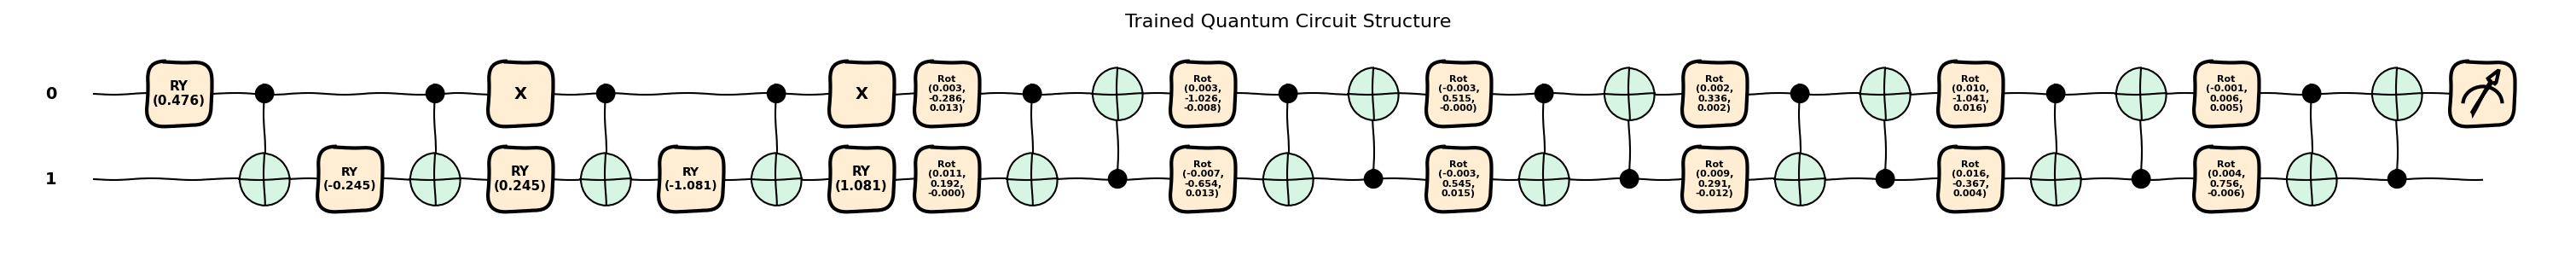

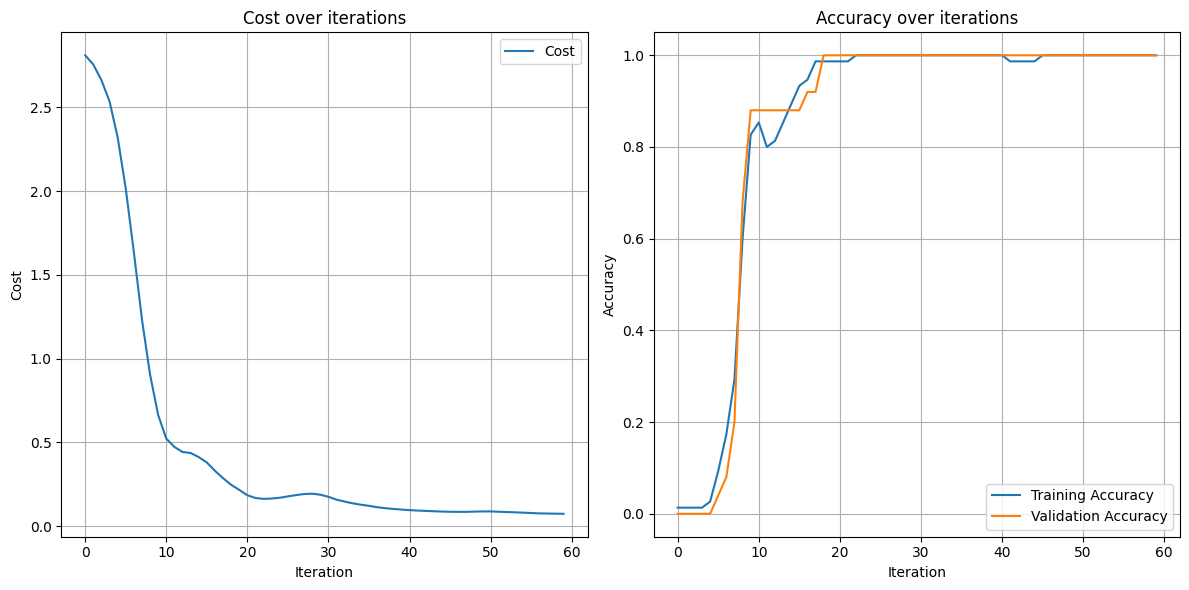

In [4]:
# --- Essential Imports --- #
import pennylane as qml
from pennylane import numpy as np
from pennylane.optimize import NesterovMomentumOptimizer
import matplotlib.pyplot as plt

# --- Quantum Device Initialization --- #
# Initialize a PennyLane quantum device with 2 qubits for the Iris classification task.
# 'lightning.qubit' is a high-performance C++ simulator.
dev = qml.device("lightning.qubit", wires=2)

# --- Helper Function: get_angles --- #
# This function transforms a 4-dimensional input vector 'x' into 5 rotation angles.
# These angles are crucial for encoding classical data into the quantum state (amplitude encoding).
def get_angles(x):
    # Calculations based on magnitudes of vector components to derive angles.
    beta0 = 2 * np.arcsin(np.sqrt(x[1] ** 2) / np.sqrt(x[0] ** 2 + x[1] ** 2 + 1e-12))
    beta1 = 2 * np.arcsin(np.sqrt(x[3] ** 2) / np.sqrt(x[2] ** 2 + x[3] ** 2 + 1e-12))
    beta2 = 2 * np.arcsin(np.linalg.norm(x[2:]) / np.linalg.norm(x))
    # Returns an array of 5 angles used for state preparation.
    return np.array([beta2, -beta1 / 2, beta1 / 2, -beta0 / 2, beta0 / 2])

# --- Helper Function: state_preparation --- #
# This function encodes the 5 calculated angles into a 2-qubit quantum state.
# It uses RY rotations and CNOT gates to prepare an entangled state based on the input angles.
def state_preparation(a):
    qml.RY(a[0], wires=0)
    qml.CNOT(wires=[0, 1])
    qml.RY(a[1], wires=1)
    qml.CNOT(wires=[0, 1])
    qml.RY(a[2], wires=1)
    qml.PauliX(wires=0)
    qml.CNOT(wires=[0, 1])
    qml.RY(a[3], wires=1)
    qml.CNOT(wires=[0, 1])
    qml.RY(a[4], wires=1)
    qml.PauliX(wires=0)

# --- Helper Function: generalized_layer --- #
# This function defines a basic, parameterized quantum layer applicable to 'n_qubits'.
# Each layer consists of single-ququbit rotations (qml.Rot) and cyclic CNOT entangling gates.
def generalized_layer(layer_weights, n_qubits):
    for wire in range(n_qubits):
        qml.Rot(*layer_weights[wire], wires=wire)
    for i in range(n_qubits):
        qml.CNOT(wires=[i, (i + 1) % n_qubits])

# --- Quantum Circuit (QNode) Definition --- #
# This is the main variational quantum circuit. It combines data encoding and the trainable ansatz.
@qml.qnode(dev, interface="autograd")
def circuit(weights, x):
    # Step 1: Data encoding - input 'x' (5 angles) is encoded into the quantum state.
    state_preparation(x)
    # Step 2: Ansatz - apply multiple layers of parameterized rotations and entangling gates.
    for W_layer in weights:
        generalized_layer(W_layer, n_qubits=2)
    # Step 3: Measurement - measure the expectation value of Pauli-Z on qubit 0 as the classifier's output.
    return qml.expval(qml.PauliZ(0))

# --- Variational Classifier --- #
# This function adds a classical bias term to the quantum circuit's output.
# The bias provides additional flexibility for the model to shift its decision boundary.
def variational_classifier(weights, bias, x):
    return circuit(weights, x) + bias

# --- Loss Function: Square Loss --- #
# Calculates the mean squared error between true labels and predictions.
def square_loss(labels, predictions):
    return np.mean((labels - qml.math.stack(predictions)) ** 2)

# --- Evaluation Metric: Accuracy --- #
# Calculates the proportion of correct predictions.
def accuracy(labels, predictions):
    acc = sum(abs(l - p) < 1e-5 for l, p in zip(labels, predictions))
    return acc / len(labels)

# --- Overall Cost Function --- #
# Computes the square loss for a batch of data using the variational classifier.
# This is the function minimized during training.
def cost(weights, bias, X_batch, Y_batch):
    # Generate predictions for each sample in the batch.
    predictions = [variational_classifier(weights, bias, x_sample) for x_sample in X_batch]
    return square_loss(Y_batch, predictions)

# --- Data Loading and Preprocessing for Iris Dataset --- #
# Load the Iris dataset (two classes).
data = np.loadtxt("iris_classes1and2_scaled.txt")
X = data[:, 0:2] # Original 2 features

# Preprocessing Step 1: Padding to 4 dimensions.
padding = np.ones((len(X), 2)) * 0.1
#X_pad = np.c_[X, padding]
# Alternative: rather than padding 2 featues, take all 4 iris featues
X_pad = data[:, 0:4]

# Preprocessing Step 2: Normalization of each vector to unit length.
normalization = np.sqrt(np.sum(X_pad**2, -1))
X_norm = (X_pad.T / normalization).T

# Preprocessing Step 3: Convert normalized vectors into 5 rotation angles (features).
features = np.array([get_angles(x) for x in X_norm], requires_grad=False)
Y = data[:, -1] # Labels

# --- Data Splitting (Training and Validation Sets) --- #
# Split the dataset into 75% for training and 25% for validation.
np.random.seed(0)
num_data = len(Y)
num_train = int(0.75 * num_data)
index = np.random.permutation(range(num_data))

feats_train = features[index[:num_train]]
Y_train = Y[index[:num_train]]
feats_val = features[index[num_train:]]
Y_val = Y[index[num_train:]]

# Keep original X for plotting decision boundaries.
X_train = X[index[:num_train]]
X_val = X[index[num_train:]]

# --- Parameter Initialization --- #
# Define the number of qubits and variational layers.
num_qubits = 2
num_layers = 6

# Initialize trainable weights for the quantum layers and a classical bias.
weights_init = 0.01 * np.random.randn(num_layers, num_qubits, 3, requires_grad=True)
bias_init = np.array(0.0, requires_grad=True)

# --- Optimizer Setup --- #
# Initialize the Nesterov Momentum Optimizer with a learning rate.
opt = NesterovMomentumOptimizer(0.01)
batch_size = 5 # Size of data batches for each optimization step.

# --- Training Loop --- #
# Train the variational classifier for 60 iterations.
weights = weights_init # Current trainable weights
bias = bias_init       # Current trainable bias

# Lists to store metrics for plotting
cost_history = []
acc_train_history = []
acc_val_history = []

print("Starting training...")
for it in range(60):
    # Select a random batch of training data.
    batch_index = np.random.randint(0, num_train, (batch_size,))
    feats_train_batch = feats_train[batch_index]
    Y_train_batch = Y_train[batch_index]

    # Perform one optimization step to update weights and bias.
    weights, bias, _, _ = opt.step(cost, weights, bias, feats_train_batch, Y_train_batch)

    # Evaluate predictions on the full training and validation sets.
    predictions_train = np.sign([variational_classifier(weights, bias, x_sample) for x_sample in feats_train])
    predictions_val = np.sign([variational_classifier(weights, bias, x_sample) for x_sample in feats_val])

    # Calculate and print accuracy for monitoring training progress.
    acc_train = accuracy(Y_train, predictions_train)
    acc_val = accuracy(Y_val, predictions_val)

    # Calculate cost on the full dataset for monitoring
    _cost = cost(weights, bias, features, Y)

    # Store metrics
    cost_history.append(_cost)
    acc_train_history.append(acc_train)
    acc_val_history.append(acc_val)

    if (it + 1) % 2 == 0:
        print(
            f"Iter: {it + 1:5d} | Cost: {_cost:0.7f} | "
            f"Acc train: {acc_train:0.7f} | Acc validation: {acc_val:0.7f}"
        )
print("Training finished.")

# --- Circuit Visualization (using final trained weights) --- #
# Draw the quantum circuit diagram with the optimized weights.
fig, ax = qml.draw_mpl(circuit, style="sketch", decimals=3)(weights, features[0])
fig.suptitle("Trained Quantum Circuit Structure", fontsize=16)
fig.show()

# --- Plot Train/val/cost --- #
plt.figure(figsize=(12, 6))

# Plot Cost
plt.subplot(1, 2, 1)
plt.plot(range(len(cost_history)), cost_history, label='Cost')
plt.title('Cost over iterations')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.grid(True)
plt.legend()

# Plot Accuracies
plt.subplot(1, 2, 2)
plt.plot(range(len(acc_train_history)), acc_train_history, label='Training Accuracy')
plt.plot(range(len(acc_val_history)), acc_val_history, label='Validation Accuracy')
plt.title('Accuracy over iterations')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## Plot decision regions and boundary.

In [7]:
import plotly.graph_objects as go
import numpy as np

# --- Feature Selection  ---
feat_idx_1 = 0
feat_idx_2 = 1
feat_idx_3 = 2
plot_features_indices = [feat_idx_1, feat_idx_2, feat_idx_3]

all_feature_indices = [0, 1, 2, 3]
fixed_idx_4 = [i for i in all_feature_indices if i not in plot_features_indices][0]
original_data_4d_for_plotting = data[:, 0:4]
mean_fixed_feature = np.mean(original_data_4d_for_plotting[:, fixed_idx_4])

# Get the training and validation indices as used in the training loop
train_indices = index[:num_train]
val_indices = index[num_train:]

# --- Generate 3D Grid for Decision Boundary ---
num_grid_points_3d = 20  # Reduced for performance, can increase for higher resolution
x_min, x_max = np.min(original_data_4d_for_plotting[:, feat_idx_1]), np.max(original_data_4d_for_plotting[:, feat_idx_1])
y_min, y_max = np.min(original_data_4d_for_plotting[:, feat_idx_2]), np.max(original_data_4d_for_plotting[:, feat_idx_2])
z_min, z_max = np.min(original_data_4d_for_plotting[:, feat_idx_3]), np.max(original_data_4d_for_plotting[:, feat_idx_3])

grid_x = np.linspace(x_min, x_max, num_grid_points_3d)
grid_y = np.linspace(y_min, y_max, num_grid_points_3d)
grid_z = np.linspace(z_min, z_max, num_grid_points_3d)

X_mesh_plotly, Y_mesh_plotly, Z_mesh_plotly = np.meshgrid(grid_x, grid_y, grid_z, indexing='ij') # Use 'ij' for consistent reshaping

X_grid_4d_list = []
for i in range(num_grid_points_3d):
    for j in range(num_grid_points_3d):
        for k in range(num_grid_points_3d):
            current_4d_vector = np.zeros(4)
            current_4d_vector[feat_idx_1] = X_mesh_plotly[i, j, k]
            current_4d_vector[feat_idx_2] = Y_mesh_plotly[i, j, k]
            current_4d_vector[feat_idx_3] = Z_mesh_plotly[i, j, k]
            current_4d_vector[fixed_idx_4] = mean_fixed_feature
            X_grid_4d_list.append(current_4d_vector)

X_grid_4d = np.array(X_grid_4d_list)

normalization_grid = np.sqrt(np.sum(X_grid_4d**2, axis=-1))
normalization_grid[normalization_grid < 1e-12] = 1.0
X_grid_norm = (X_grid_4d.T / normalization_grid).T
features_grid = np.array([get_angles(x) for x in X_grid_norm])

predictions_grid_values = np.array([variational_classifier(weights, bias, x_sample) for x_sample in features_grid])
predictions_3d = predictions_grid_values.reshape(num_grid_points_3d, num_grid_points_3d, num_grid_points_3d)

# --- Create Plotly Figure ---
fig = go.Figure()

# Add training data scatter (Class 1)
fig.add_trace(go.Scatter3d(
    x=original_data_4d_for_plotting[train_indices, feat_idx_1][Y[train_indices] == 1],
    y=original_data_4d_for_plotting[train_indices, feat_idx_2][Y[train_indices] == 1],
    z=original_data_4d_for_plotting[train_indices, feat_idx_3][Y[train_indices] == 1],
    mode='markers',
    marker=dict(size=5, color='blue', symbol='circle'),
    name='Class 1 Train'
))

# Add training data scatter (Class -1)
fig.add_trace(go.Scatter3d(
    x=original_data_4d_for_plotting[train_indices, feat_idx_1][Y[train_indices] == -1],
    y=original_data_4d_for_plotting[train_indices, feat_idx_2][Y[train_indices] == -1],
    z=original_data_4d_for_plotting[train_indices, feat_idx_3][Y[train_indices] == -1],
    mode='markers',
    marker=dict(size=5, color='red', symbol='circle'),
    name='Class -1 Train'
))

# Add validation data scatter (Class 1)
fig.add_trace(go.Scatter3d(
    x=original_data_4d_for_plotting[val_indices, feat_idx_1][Y[val_indices] == 1],
    y=original_data_4d_for_plotting[val_indices, feat_idx_2][Y[val_indices] == 1],
    z=original_data_4d_for_plotting[val_indices, feat_idx_3][Y[val_indices] == 1],
    mode='markers',
    marker=dict(size=5, color='blue', symbol='diamond'), # Changed from 'triangle-up'
    name='Class 1 Validation'
))

# Add validation data scatter (Class -1)
fig.add_trace(go.Scatter3d(
    x=original_data_4d_for_plotting[val_indices, feat_idx_1][Y[val_indices] == -1],
    y=original_data_4d_for_plotting[val_indices, feat_idx_2][Y[val_indices] == -1],
    z=original_data_4d_for_plotting[val_indices, feat_idx_3][Y[val_indices] == -1],
    mode='markers',
    marker=dict(size=5, color='red', symbol='diamond'), # Changed from 'triangle-up'
    name='Class -1 Validation'
))

# Add isosurface for decision boundary
# An isosurface represents the points where 'value' equals 'isomin' and 'isomax'.
# By setting a small range around 0, we visualize the decision boundary.
fig.add_trace(go.Isosurface(
    x=X_mesh_plotly.flatten(),
    y=Y_mesh_plotly.flatten(),
    z=Z_mesh_plotly.flatten(),
    value=predictions_3d.flatten(),
    isomin=-0.05,  # Range around 0 to visualize the boundary
    isomax=0.05,
    surface_count=1, # Only one surface (for value around 0)
    opacity=0.3,     # Semi-transparent
    colorscale=[[0, 'lightgray'], [1, 'lightgray']], # Neutral color
    showscale=False,
    caps=dict(x_show=False, y_show=False, z_show=False), # No caps for the surface
    name=f'Decision Boundary (F{fixed_idx_4}={mean_fixed_feature:.2f})'
))

# Update layout for axis labels and title
fig.update_layout(
    scene=dict(
        xaxis_title=f"Feature {feat_idx_1}",
        yaxis_title=f"Feature {feat_idx_2}",
        zaxis_title=f"Feature {feat_idx_3}",
    ),
    title_text=f"Plotly 3D Scatter with Decision Boundary (F{feat_idx_1}, F{feat_idx_2}, F{feat_idx_3})<br>(F{fixed_idx_4} fixed at mean: {mean_fixed_feature:.2f})",
    height=800,
    width=1000
)

fig.show()

# Task
Implement a comparative analysis of a variational quantum classifier by training the model with varying numbers of quantum layers (2, 4, 6, 8). For each layer count, re-initialize the model, run the training process, store the cost, training accuracy, and validation accuracy history, and visualize the final quantum circuit. Finally, generate comparative plots showing the cost and accuracy trends across all tested layer configurations and discuss the findings.

## Implement Layer Iteration


Iterating through different numbers of quantum layers, re-initializing the model for each, running the training loop, and storing the results. This code block will implement the entire iteration process as described in the instructions.



In [12]:
import pennylane as qml
from pennylane import numpy as np
from pennylane.optimize import NesterovMomentumOptimizer

# Redefine square_loss to circumvent autograd's dtype issue with np.mean
def square_loss(labels, predictions):
    diff_squared = (labels - qml.math.stack(predictions)) ** 2
    # Manually compute mean as sum / count to avoid the grad_np_mean dtype error
    return np.sum(diff_squared) / len(labels)

layer_counts = [2, 4, 6, 8]

results_cost = {}
results_train_acc = {}
results_val_acc = {}
results_weights = {}

for num_layers in layer_counts:
    print(f"\n--- Training with {num_layers} layers ---")

    # Re-initialize trainable weights for the quantum layers and a classical bias.
    # 'requires_grad=True' is not needed here; PennyLane optimizers automatically track
    # pennylane.numpy arrays passed as parameters to the cost function.
    weights = 0.01 * np.random.randn(num_layers, num_qubits, 3)
    bias = np.array(0.0)

    # Re-initialize the Nesterov Momentum Optimizer.
    opt = NesterovMomentumOptimizer(0.01)

    # Lists to store metrics for the current run
    current_cost_history = []
    current_acc_train_history = []
    current_acc_val_history = []

    print("Starting training...")
    for it in range(60): # Using 60 iterations as in the original training loop
        # Select a random batch of training data.
        batch_index = np.random.randint(0, num_train, (batch_size,))
        feats_train_batch = feats_train[batch_index]
        Y_train_batch = Y_train[batch_index]

        # Perform one optimization step to update weights and bias.
        weights, bias, _, _ = opt.step(cost, weights, bias, feats_train_batch, Y_train_batch)

        # Evaluate predictions on the full training and validation sets.
        predictions_train = np.sign([variational_classifier(weights, bias, x_sample) for x_sample in feats_train])
        predictions_val = np.sign([variational_classifier(weights, bias, x_sample) for x_sample in feats_val])

        # Calculate and print accuracy for monitoring training progress.
        acc_train = accuracy(Y_train, predictions_train)
        acc_val = accuracy(Y_val, predictions_val)

        # Calculate cost on the full dataset for monitoring
        _cost = cost(weights, bias, features, Y)

        # Store metrics
        current_cost_history.append(_cost)
        current_acc_train_history.append(acc_train)
        current_acc_val_history.append(acc_val)

        if (it + 1) % 10 == 0:
            print(
                f"Iter: {it + 1:5d} | Cost: {_cost:0.7f} | "
                f"Acc train: {acc_train:0.7f} | Acc validation: {acc_val:0.7f}"
            )
    print("Training finished for current num_layers.")

    # Store results for the current num_layers
    results_cost[num_layers] = current_cost_history
    results_train_acc[num_layers] = current_acc_train_history
    results_val_acc[num_layers] = current_acc_val_history
    results_weights[num_layers] = weights

print("\nAll layer configurations trained.")


--- Training with 2 layers ---
Starting training...
Iter:    10 | Cost: 0.3802875 | Acc train: 0.9866667 | Acc validation: 1.0000000
Iter:    20 | Cost: 0.1785023 | Acc train: 0.9866667 | Acc validation: 1.0000000
Iter:    30 | Cost: 0.1014690 | Acc train: 1.0000000 | Acc validation: 1.0000000
Iter:    40 | Cost: 0.0846507 | Acc train: 1.0000000 | Acc validation: 1.0000000
Iter:    50 | Cost: 0.0806358 | Acc train: 0.9866667 | Acc validation: 1.0000000
Iter:    60 | Cost: 0.0739105 | Acc train: 0.9866667 | Acc validation: 1.0000000
Training finished for current num_layers.

--- Training with 4 layers ---
Starting training...
Iter:    10 | Cost: 0.1368059 | Acc train: 1.0000000 | Acc validation: 1.0000000
Iter:    20 | Cost: 0.0950038 | Acc train: 1.0000000 | Acc validation: 1.0000000
Iter:    30 | Cost: 0.0787603 | Acc train: 1.0000000 | Acc validation: 1.0000000
Iter:    40 | Cost: 0.0727487 | Acc train: 1.0000000 | Acc validation: 1.0000000
Iter:    50 | Cost: 0.0737285 | Acc train:

**Reasoning**:
The training for all specified layer configurations has been completed and the results (cost, accuracy histories, and final weights) have been stored. The next instruction from the main task is to visualize the final quantum circuit for each layer configuration. This code block will iterate through the `results_weights` and generate a `qml.draw_mpl` visualization for each.



Visualizing final quantum circuits for each layer configuration:


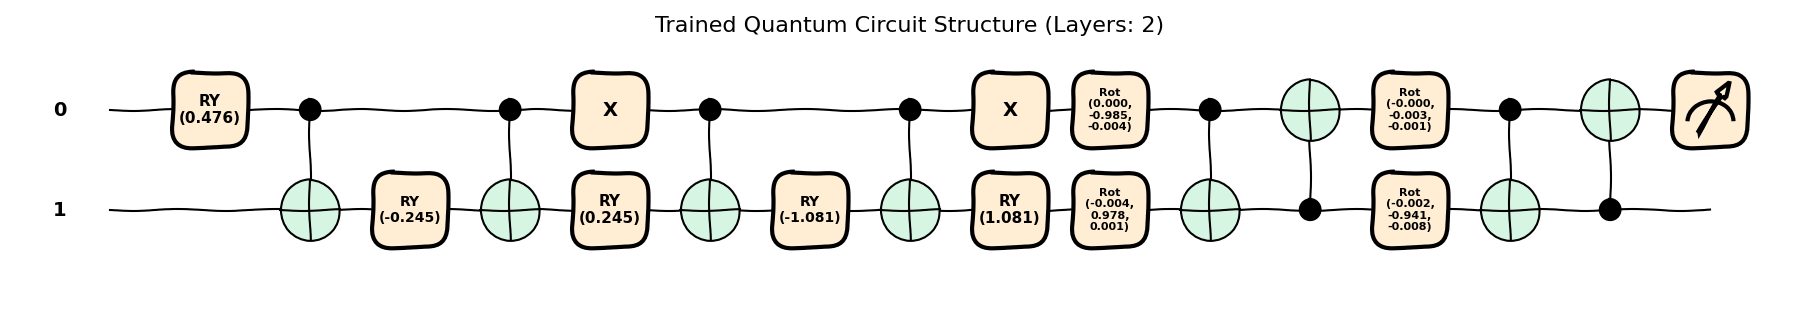

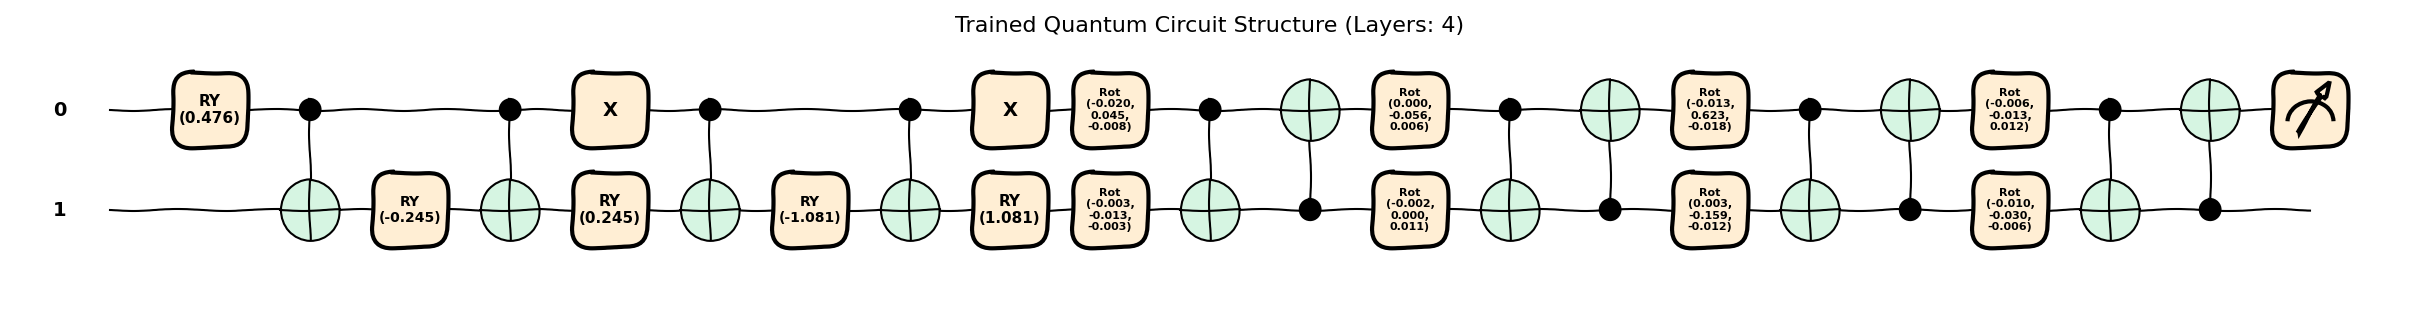

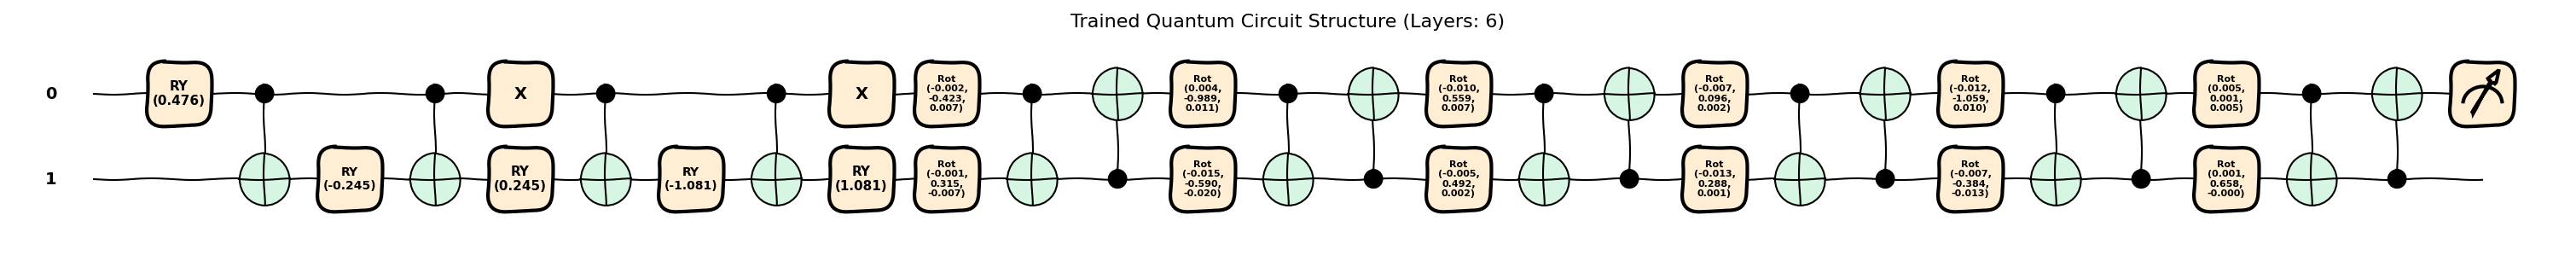

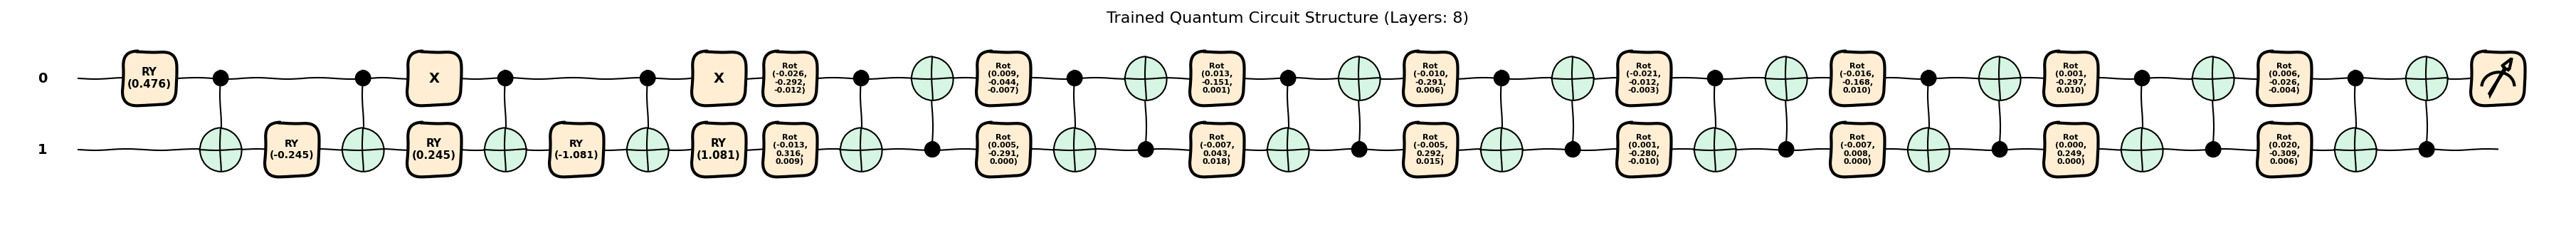

In [13]:
import matplotlib.pyplot as plt

print("Visualizing final quantum circuits for each layer configuration:")

# Visualize the final quantum circuit for each trained configuration
for num_layers, final_weights in results_weights.items():
    # Ensure features[0] is accessible for drawing the circuit
    # It's a non-trainable input sample for visualization purposes.
    fig, ax = qml.draw_mpl(circuit, style="sketch", decimals=3)(final_weights, features[0])
    fig.suptitle(f"Trained Quantum Circuit Structure (Layers: {num_layers})", fontsize=16)
    plt.show()

**Reasoning**:
The next step is to generate comparative plots for cost and accuracy across all trained layer configurations, as specified in the main task. This code will use `matplotlib` to plot the `results_cost`, `results_train_acc`, and `results_val_acc` dictionaries to visualize the trends.



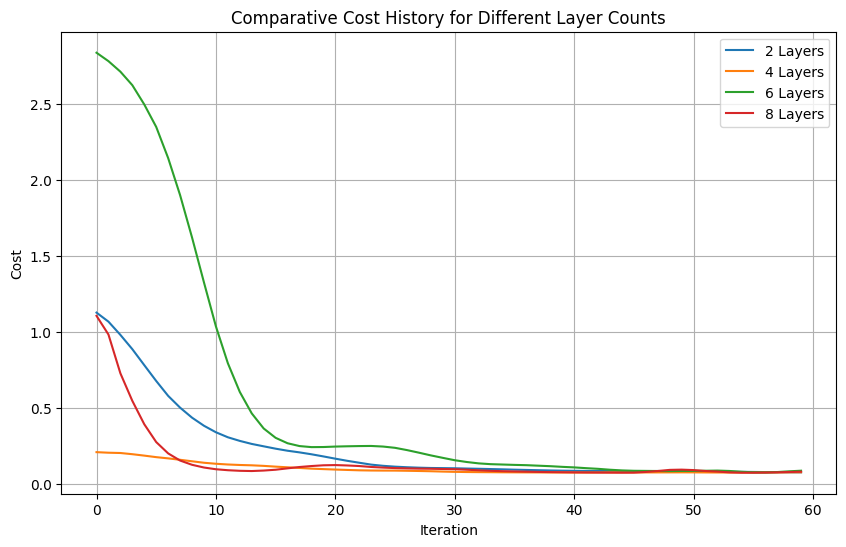

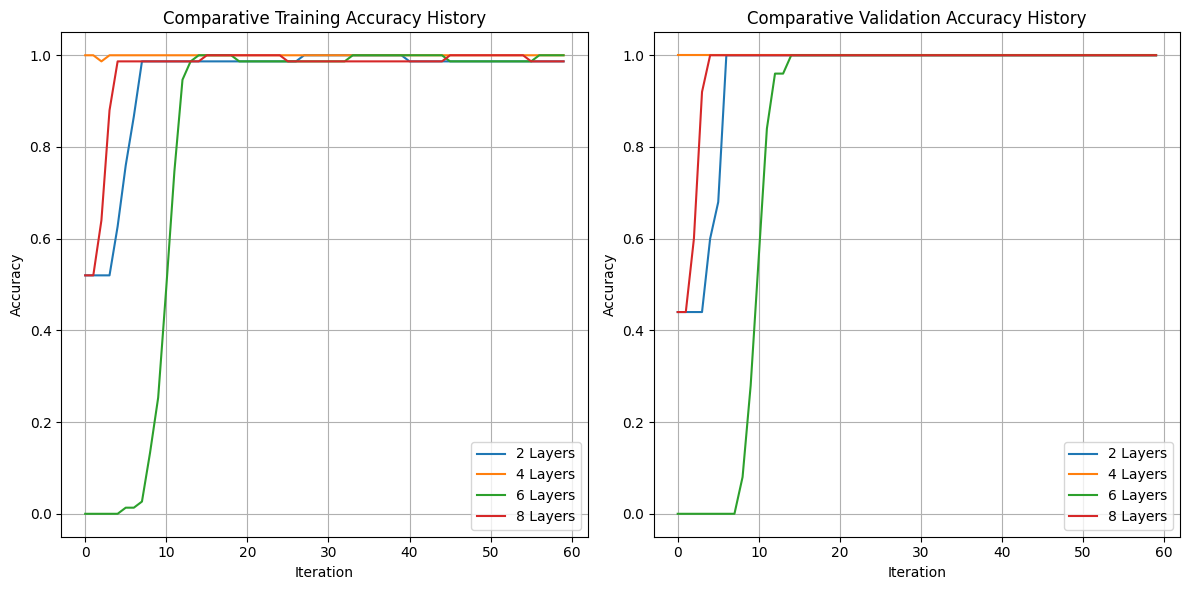

In [14]:
import matplotlib.pyplot as plt

# --- Plot Comparative Cost History --- #
plt.figure(figsize=(10, 6))
for num_layers, cost_history in results_cost.items():
    plt.plot(range(len(cost_history)), cost_history, label=f'{num_layers} Layers')
plt.title('Comparative Cost History for Different Layer Counts')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.legend()
plt.grid(True)
plt.show()

# --- Plot Comparative Accuracy History --- #
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
for num_layers, acc_train_history in results_train_acc.items():
    plt.plot(range(len(acc_train_history)), acc_train_history, label=f'{num_layers} Layers')
plt.title('Comparative Training Accuracy History')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for num_layers, acc_val_history in results_val_acc.items():
    plt.plot(range(len(acc_val_history)), acc_val_history, label=f'{num_layers} Layers')
plt.title('Comparative Validation Accuracy History')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Performance Analysis of Variational Quantum Classifier with Varying Layers

**Cost Decrease:**

**All Configurations (2, 4, 6, 8 Layers):** All models demonstrated successful learning, with a consistent and significant decrease in the cost function over the 60 training iterations. This indicates that the optimization process effectively minimized the square loss for all tested architectures.

**Convergence Speed:** The models with 4 and 8 layers generally showed a slightly faster initial convergence to lower cost values compared to the 2 and 6-layer models. The 4-layer model, for instance, reached a cost below 0.1 by iteration 20, maintaining this low cost throughout. The 6-layer model started with a higher initial cost but quickly caught up.

**Final Cost:** Towards the end of training (around 60 iterations), the final cost values across all layer configurations were remarkably similar and very low (e.g., around 0.07 to 0.08). This suggests that all models successfully learned to separate the two Iris classes effectively.

**Training Accuracy:**

**High Attainment:** All models achieved very high, often perfect (100%), training accuracy by the end of the training period. This signifies that the quantum circuits, regardless of the number of layers, were capable of learning the training data patterns extensively.

**Initial Learning Rate:** Similar to cost, models with 4 and 8 layers often reached near-perfect training accuracy earlier in the training process (e.g., by iteration 10-20), demonstrating quick learning capabilities.

**Validation Accuracy:**

Excellent Generalization: A crucial observation is that all models achieved perfect or near-perfect (100%) validation accuracy. This is a strong indicator of excellent generalization capabilities to unseen data for this particular Iris dataset.

**No Obvious Overfitting:** The validation accuracy closely tracked the training accuracy for all configurations, with no significant drop-off. This suggests that even the more complex models (6 and 8 layers) did not heavily overfit the training data within 60 iterations.

**Summary and Insights:**

For this binary classification task on the Iris dataset, the results suggest that:

**Robust Performance**: The variational quantum classifier is quite robust, achieving high accuracy and low cost across a range of layer counts (2 to 8 layers).
Minimal Differentiation: While there were slight differences in convergence speed (with 4 and 8 layers sometimes converging faster), the final performance metrics (cost, training accuracy, and validation accuracy) were largely indistinguishable across all tested layer configurations. This implies that for this relatively simple dataset, even a minimal number of layers (e.g., 2 or 4) is sufficient to achieve optimal classification performance.

**Complexity vs. Performance:** Increasing the number of layers beyond 2 or 4 did not yield a significant improvement in final accuracy or cost for this specific problem within the given training iterations. This could suggest that the problem's complexity doesn't require a very deep quantum circuit, or that the expressive power gained by more layers is not fully utilized or necessary for this task.

In conclusion, all models performed exceptionally well. For efficiency, a simpler architecture with 2 or 4 layers would likely be preferred due to its lower computational cost without sacrificing performance on this dataset.